In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

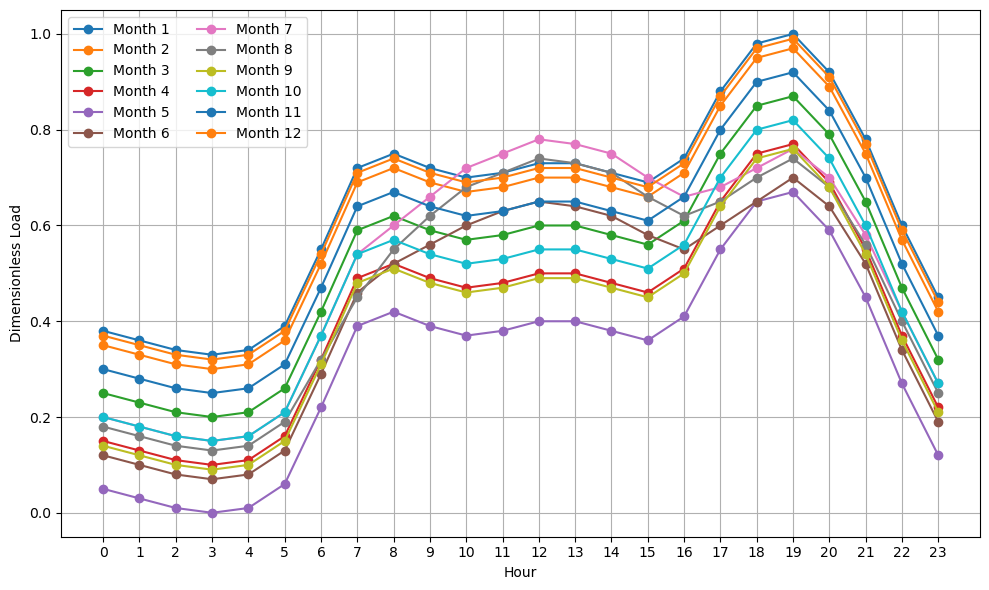

In [12]:
# Load CSV
df = pd.read_csv("universal_load_288.csv")

# Plot
plt.figure(figsize=(10, 6))

for month, group in df.groupby("Month"):
    plt.plot(
        group["Hour"],
        group["Dimensionless_Load"],
        marker="o",
        label=f"Month {month}"
    )

plt.xlabel("Hour")
plt.ylabel("Dimensionless Load")
plt.xticks(range(24))
plt.grid(True)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

## Group 15 => La Palma (Canaries)

### Table 4: Island Grid Sizing Constraints and Hydrological Parameters

| Archipelago | Island Name | Base Load (Pbase) | Peak Load (Ppeak) | Gross Head (Hb) |
| ----------- | ----------- | ----------------: | ----------------: | --------------: |
| Azores      | Flores      |            1.2 MW |            3.8 MW |           120 m |
| Azores      | São Jorge   |            1.5 MW |            4.5 MW |           150 m |
| Canaries    | El Hierro   |            3.5 MW |            8.2 MW |           150 m |
| Canaries    | La Palma    |            4.0 MW |           11.5 MW |           200 m |

### Table 5: Synthetic Monthly Average River Flow Rates (m³/s)

| Island    |  Jan |  Feb |  Mar |  Apr |  May |  Jun |  Jul |  Aug |  Sep |  Oct |  Nov |  Dec |
| --------- | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| Flores    | 0.85 | 0.90 | 0.75 | 0.55 | 0.35 | 0.20 | 0.12 | 0.10 | 0.18 | 0.35 | 0.60 | 0.80 |
| São Jorge | 0.60 | 0.65 | 0.50 | 0.40 | 0.25 | 0.15 | 0.10 | 0.08 | 0.15 | 0.30 | 0.45 | 0.55 |
| El Hierro | 0.50 | 0.55 | 0.40 | 0.28 | 0.18 | 0.10 | 0.05 | 0.04 | 0.08 | 0.20 | 0.35 | 0.48 |
| La Palma  | 0.70 | 0.75 | 0.60 | 0.45 | 0.30 | 0.20 | 0.12 | 0.10 | 0.18 | 0.35 | 0.50 | 0.65 |


In [13]:
P_base = 4e6 # Base Load = 4 MW
P_peak = 11.5e6 # Peak Load = 11.5 MW

# P_demand = P_base + M( month, hour) * (P_peak - P_base)
# Calculate demand
df["P_demand"] = ( P_base + df["Dimensionless_Load"] * (P_peak - P_base))

print(df)

     Month  Hour  Dimensionless_Load    P_demand
0        1     0                0.38   6850000.0
1        1     1                0.36   6700000.0
2        1     2                0.34   6550000.0
3        1     3                0.33   6475000.0
4        1     4                0.34   6550000.0
..     ...   ...                 ...         ...
283     12    19                0.99  11425000.0
284     12    20                0.91  10825000.0
285     12    21                0.77   9775000.0
286     12    22                0.59   8425000.0
287     12    23                0.44   7300000.0

[288 rows x 4 columns]


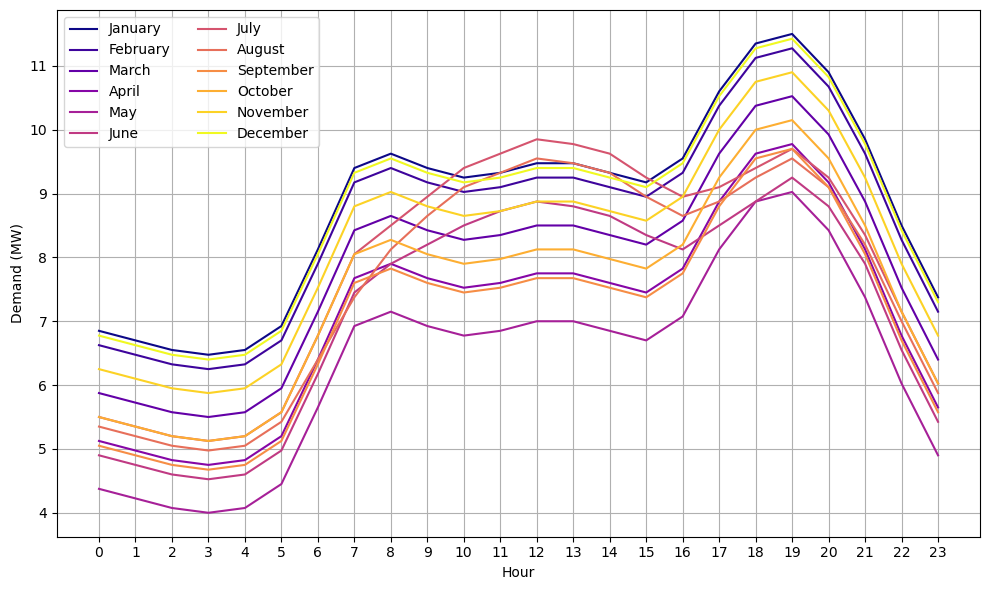

In [38]:
month_names = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]


plt.figure(figsize=(10, 6))

cmap = plt.colormaps["plasma"]
for month, group in df.groupby("Month"):
    plt.plot(
        group["Hour"],
        group["P_demand"]*1e-6,
        color=cmap((month - 1) / 11),
        label=month_names[month - 1]
    )

plt.xlabel("Hour")
plt.ylabel("Demand (MW)")
plt.xticks(range(24))
plt.grid(True)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

In [47]:
# To calculate the final annual energy volume (E_annual [MWh]) for your economic models, integrate
# the scaled hours using the standard number of days per month (Nm):

days_per_month = {
    1: 31,
    2: 28,  # 29 in leap years
    3: 31,
    4: 30,
    5: 31,
    6: 30,
    7: 31,
    8: 31,
    9: 30,
    10: 31,
    11: 30,
    12: 31}

E_monthly = (df.groupby("Month")["P_demand"].sum().mul(pd.Series(days_per_month)))
E_annual = E_monthly.sum()

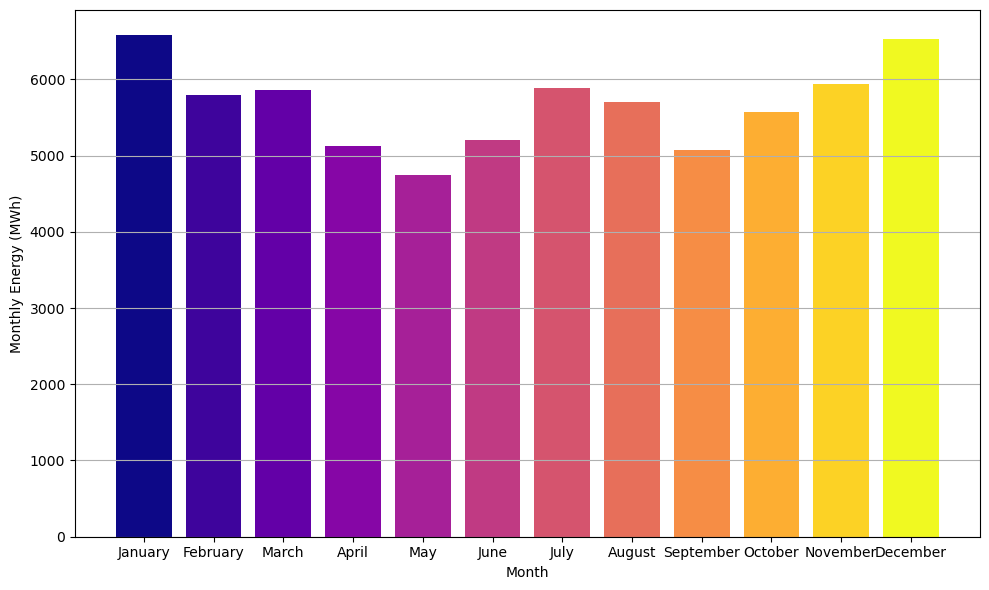

In [54]:
months = df["Month"].unique().tolist()

plt.figure(figsize=(10, 6))
plt.bar( months, E_monthly * 1e-6, color=[cmap((month - 1) / 11) for month in months]
)

plt.xlabel("Month")
plt.ylabel("Monthly Energy (MWh)")
plt.xticks(months, month_names)
plt.grid(axis="y")
plt.tight_layout()
plt.show()